# EnergiAI – Inteligencia para el Consumo Energético
### Hackathon ONE – Proyectos G9 | Team 72

## 1. Análisis Exploratorio de Datos (EDA) y Limpieza
- Carga del dataset sintético/público.
- Tratamiento de variables (consumo_kwh, uso_horario_pico, cantidad_equipos, tipo_inmueble, horas_alto_consumo).

## 2. Entrenamiento del Modelo Predictivo
- Criterios de clasificación (Eficiente, Moderado, Ineficiente).
- Modelos a evaluar: Random Forest / Árboles de Decisión / Regresión Logística.

## 3. Serialización del Modelo
- Exportación final a formato `.pkl` o `.joblib` para el equipo de Backend.

## 1. Análisis Exploratorio de Datos (EDA) y Limpieza

Por Zuleyca Guadalupe Balles Soto

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter

pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)
plt.rcParams.update({
    "figure.figsize": (9, 4.5),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 10,
})

# Paleta consistente para el perfil de eficiencia
PERF_COLORS = {"Eficiente": "#2e8b57", "Moderado": "#e0a800", "Ineficiente": "#c0392b"}
PERF_ORDER = ["Eficiente", "Moderado", "Ineficiente"]
print("Librerias cargadas.")

Librerias cargadas.


### 1. Carga de datos

In [ ]:
# Resolucion robusta de la ruta de datos
CANDIDATES = ["data_Team_72_EnergiAI", "data/data_Team_72_EnergiAI", ".", "data"]
DATA_DIR = next((c for c in CANDIDATES if os.path.exists(os.path.join(c, "dataset_team_72.csv"))), None)
assert DATA_DIR is not None, "No encuentro los CSV. Coloca la carpeta data_Team_72_EnergiAI junto al notebook."
print("Usando DATA_DIR =", os.path.abspath(DATA_DIR))

est = pd.read_csv(os.path.join(DATA_DIR, "establecimientos.csv"))
eq  = pd.read_csv(os.path.join(DATA_DIR, "inventario_equipos.csv"))
con = pd.read_csv(os.path.join(DATA_DIR, "consumo_mensual.csv"))
cur = pd.read_csv(os.path.join(DATA_DIR, "curva_carga_horaria.csv"))
ds  = pd.read_csv(os.path.join(DATA_DIR, "dataset_team_72.csv"))

tablas = {"establecimientos": est, "inventario_equipos": eq,
          "consumo_mensual": con, "curva_carga_horaria": cur, "dataset (consolidado)": ds}
for n, df in tablas.items():
    print(f"{n:26s} {df.shape[0]:>6,} filas x {df.shape[1]:>2} columnas")

Usando DATA_DIR = /content
establecimientos            5,000 filas x  6 columnas
inventario_equipos         13,360 filas x  8 columnas
consumo_mensual             5,000 filas x  8 columnas
curva_carga_horaria        20,000 filas x  4 columnas
dataset (consolidado)       5,000 filas x 24 columnas



```
# Esto tiene formato de código
```

### 2. Perfilado de variables

Para cada tabla revisamos tipo de dato, valores nulos, cardinalidad y estadísticos básicos.

In [ ]:
def perfilar(df, nombre):
    print("="*70)
    print(f"TABLA: {nombre}   ({df.shape[0]:,} filas x {df.shape[1]} columnas)")
    print("="*70)
    resumen = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "nulos": df.isna().sum(),
        "%_nulos": (df.isna().mean()*100).round(2),
        "unicos": df.nunique(),
        "ejemplo": [df[c].dropna().iloc[0] if df[c].notna().any() else None for c in df.columns],
    })
    return resumen

perfilar(est, "establecimientos")

TABLA: establecimientos   (5,000 filas x 6 columnas)


,dtype,nulos,%_nulos,unicos,ejemplo
id_inmueble,object,0,0.0,5000,VIV-00001
tipo_establecimiento,object,0,0.0,2,Vivienda
categoria_comercio,object,0,0.0,4,No Aplica
superficie_m2,int64,0,0.0,137,97
habitantes_empleados,int64,0,0.0,12,6
pais_ubicacion,object,0,0.0,6,Peru


In [ ]:
perfilar(eq, "inventario_equipos")

TABLA: inventario_equipos   (13,360 filas x 8 columnas)


,dtype,nulos,%_nulos,unicos,ejemplo
id_equipo,object,0,0.0,13360,EQ-00001
id_inmueble,object,0,0.0,5000,VIV-00001
tipo_equipo,object,0,0.0,6,Iluminacion
cantidad_equipos,int64,0,0.0,30,11
potencia_watts,int64,0,0.0,8,15
tecnologia_inverter,bool,0,0.0,2,True
horas_uso_estimadas_dia,float64,0,0.0,304,5.02
consumo_kwh_dia_equipo,float64,0,0.0,3017,0.8283


In [ ]:
perfilar(con, "consumo_mensual")

TABLA: consumo_mensual   (5,000 filas x 8 columnas)


,dtype,nulos,%_nulos,unicos,ejemplo
id_registro,object,0,0.0,5000,REG-00001
id_inmueble,object,0,0.0,5000,VIV-00001
anio_mes_dd,object,0,0.0,1,2026-07-01
consumo_kwh_mes,float64,0,0.0,4386,330.85
costo_factura_usd,float64,0,0.0,4286,248.14
costo_factura_moneda_local,float64,0,0.0,4863,930.52
codigo_moneda,object,0,0.0,6,PEN
perfil_calculado,object,0,0.0,3,Ineficiente


In [ ]:
perfilar(cur, "curva_carga_horaria")

TABLA: curva_carga_horaria   (20,000 filas x 4 columnas)


,dtype,nulos,%_nulos,unicos,ejemplo
id_curva,object,0,0.0,20000,C-00001
id_inmueble,object,0,0.0,5000,VIV-00001
franja_horaria,object,0,0.0,4,Madrugada
porcentaje_distribucion,float64,0,0.0,4541,0.1332


In [ ]:
perfilar(ds, "dataset_team_72 (consolidado)")

TABLA: dataset_team_72 (consolidado)   (5,000 filas x 24 columnas)


,dtype,nulos,%_nulos,unicos,ejemplo
id_registro,object,0,0.0,5000,REG-00001
id_inmueble,object,0,0.0,5000,VIV-00001
anio_mes_dd,object,0,0.0,1,2026-07-01
pais_ubicacion,object,0,0.0,6,Peru
tipo_establecimiento,object,0,0.0,2,Vivienda
categoria_comercio,object,0,0.0,4,No Aplica
superficie_m2,int64,0,0.0,137,97
habitantes_empleados,int64,0,0.0,12,6
total_equipos,int64,0,0.0,31,13
potencia_total_watts,int64,0,0.0,205,1715


In [ ]:
# Estadisticos descriptivos de las variables numericas clave
num_cols = ["superficie_m2","habitantes_empleados","total_equipos","potencia_total_watts",
            "porcentaje_inverter","consumo_kwh_dia","consumo_kwh_mes",
            "intensidad_energetica_kwh_m2","costo_factura_usd"]
ds[num_cols].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
superficie_m2,5000.0,83.05,29.11,25.00,61.00,82.00,104.00,179.00
habitantes_empleados,5000.0,5.19,3.06,1.00,3.00,5.00,7.00,12.00
total_equipos,5000.0,23.31,6.45,12.00,18.00,23.00,29.00,42.00
potencia_total_watts,5000.0,3105.46,2846.73,450.00,1665.00,1820.00,2580.00,9450.00
porcentaje_inverter,5000.0,0.58,0.23,0.33,0.33,0.67,0.67,1.00
consumo_kwh_dia,5000.0,28.91,27.90,3.17,8.47,12.21,56.17,77.60
consumo_kwh_mes,5000.0,867.42,837.13,95.04,254.01,366.37,1685.08,2327.87
intensidad_energetica_kwh_m2,5000.0,12.90,15.26,0.87,3.05,4.58,19.98,88.90
costo_factura_usd,5000.0,650.56,627.85,71.28,190.51,274.78,1263.81,1745.90


### 3. Calidad e integridad de la data

Confirmamos que la data corregida no tiene nulos, llaves duplicadas ni referencias huérfanas, y que la cardinalidad entre tablas es la esperada (1 registro de consumo, 4 franjas horarias y al menos 1 equipo por inmueble).

In [ ]:
checks = []
# Nulos
for n, df in tablas.items():
    checks.append((f"Nulos en {n}", int(df.isna().sum().sum()), 0))
# PK unicas
for n, df, col in [("establecimientos",est,"id_inmueble"),("inventario_equipos",eq,"id_equipo"),
                   ("consumo_mensual",con,"id_registro"),("curva_carga_horaria",cur,"id_curva")]:
    checks.append((f"PK duplicadas en {n}.{col}", int(df[col].duplicated().sum()), 0))
# FK integridad
valid = set(est.id_inmueble)
for n, df in [("inventario_equipos",eq),("consumo_mensual",con),("curva_carga_horaria",cur)]:
    checks.append((f"FK huerfanas en {n}", len(set(df.id_inmueble)-valid), 0))
# Cardinalidad
checks.append(("Inmuebles sin equipos", len(valid-set(eq.id_inmueble)), 0))
checks.append(("Inmuebles con != 4 franjas", int((cur.groupby('id_inmueble').size()!=4).sum()), 0))
checks.append(("Inmuebles con != 1 consumo", int((con.groupby('id_inmueble').size()!=1).sum()), 0))

res = pd.DataFrame(checks, columns=["verificacion","valor","esperado"])
res["estado"] = np.where(res.valor==res.esperado, "OK", "REVISAR")
res

,verificacion,valor,esperado,estado
0,Nulos en establecimientos,0,0,OK
1,Nulos en inventario_equipos,0,0,OK
2,Nulos en consumo_mensual,0,0,OK
3,Nulos en curva_carga_horaria,0,0,OK
4,Nulos en dataset (consolidado),0,0,OK
5,PK duplicadas en establecimientos.id_inmueble,0,0,OK
6,PK duplicadas en inventario_equipos.id_equipo,0,0,OK
7,PK duplicadas en consumo_mensual.id_registro,0,0,OK
8,PK duplicadas en curva_carga_horaria.id_curva,0,0,OK
9,FK huerfanas en inventario_equipos,0,0,OK


### 4. Análisis univariado — Establecimientos

Composición de la cartera: tipo de inmueble, categoría comercial, país y variables físicas.

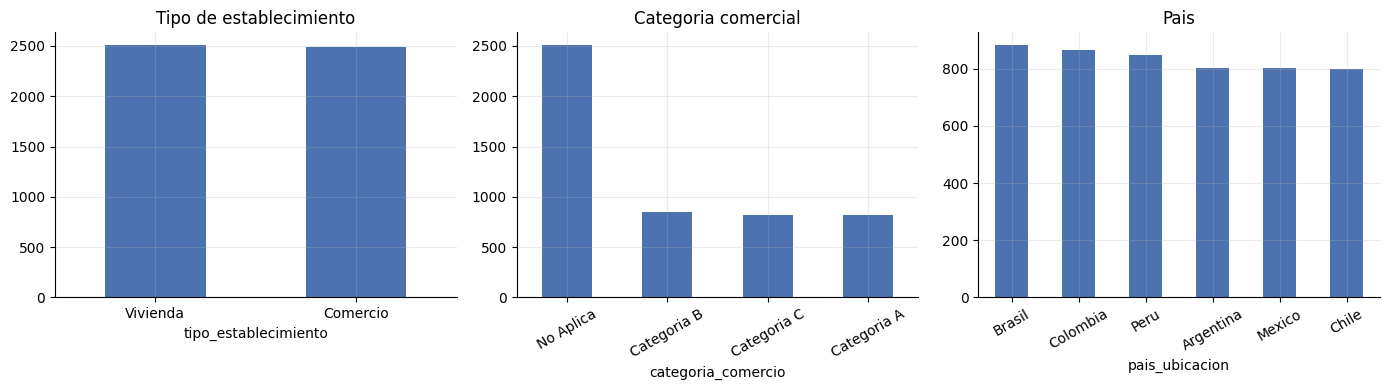

Proporcion Vivienda vs Comercio:
tipo_establecimiento
Vivienda    50.2
Comercio    49.8


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

est.tipo_establecimiento.value_counts().plot.bar(ax=axes[0], color="#4c72b0")
axes[0].set_title("Tipo de establecimiento"); axes[0].tick_params(axis='x', rotation=0)

est.categoria_comercio.value_counts().plot.bar(ax=axes[1], color="#4c72b0")
axes[1].set_title("Categoria comercial"); axes[1].tick_params(axis='x', rotation=30)

est.pais_ubicacion.value_counts().plot.bar(ax=axes[2], color="#4c72b0")
axes[2].set_title("Pais"); axes[2].tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.show()

print("Proporcion Vivienda vs Comercio:")
print((est.tipo_establecimiento.value_counts(normalize=True)*100).round(1).to_string())

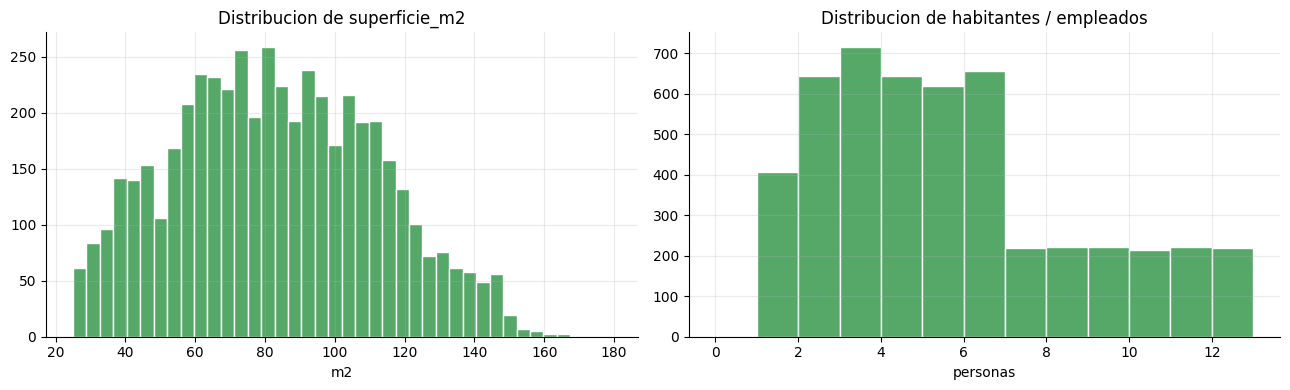

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(est.superficie_m2, bins=40, color="#55a868", edgecolor="white")
axes[0].set_title("Distribucion de superficie_m2"); axes[0].set_xlabel("m2")
axes[1].hist(est.habitantes_empleados, bins=range(0,14), color="#55a868", edgecolor="white")
axes[1].set_title("Distribucion de habitantes / empleados"); axes[1].set_xlabel("personas")
plt.tight_layout(); plt.show()

### 5. Análisis univariado — Inventario de equipos

Mezcla de equipos, potencia declarada y penetración de tecnología Inverter (variable clave de eficiencia).

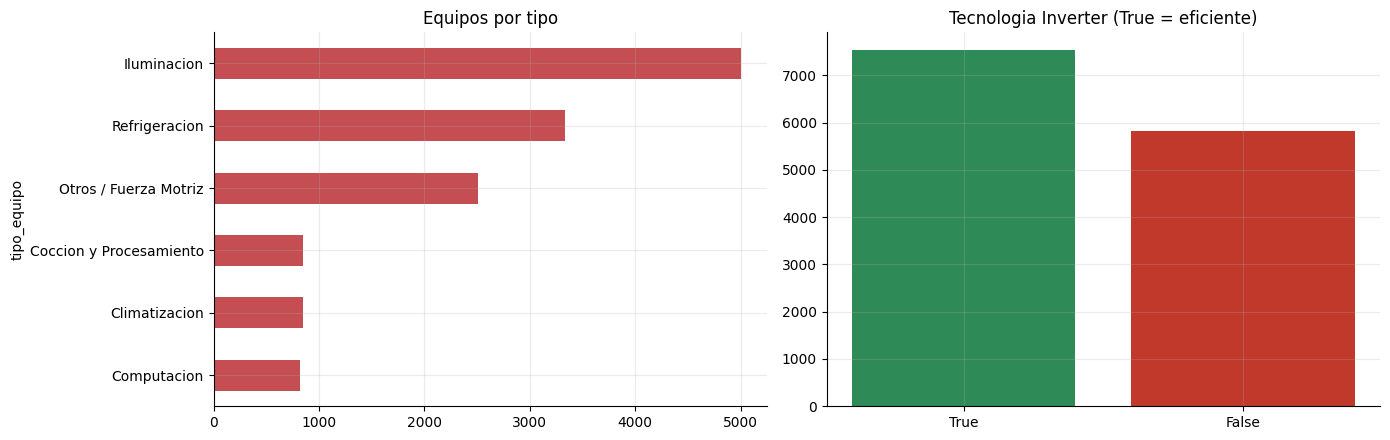

Penetracion Inverter global: 56.4% de los equipos


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
eq.tipo_equipo.value_counts().plot.barh(ax=axes[0], color="#c44e52")
axes[0].set_title("Equipos por tipo"); axes[0].invert_yaxis()

inv = eq.tecnologia_inverter.value_counts()
axes[1].bar(inv.index.astype(str), inv.values, color=["#2e8b57","#c0392b"])
axes[1].set_title("Tecnologia Inverter (True = eficiente)")
plt.tight_layout(); plt.show()

print("Penetracion Inverter global: {:.1f}% de los equipos".format(eq.tecnologia_inverter.mean()*100))

In [ ]:
# Potencia por tipo de equipo (mediana) y horas de uso
tab = eq.groupby("tipo_equipo").agg(
    potencia_mediana_w=("potencia_watts","median"),
    horas_uso_mediana=("horas_uso_estimadas_dia","median"),
    kwh_dia_medio=("consumo_kwh_dia_equipo","mean"),
    n=("id_equipo","size")).round(2).sort_values("kwh_dia_medio", ascending=False)
tab

,potencia_mediana_w,horas_uso_mediana,kwh_dia_medio,n
tipo_equipo,,,,
Climatizacion,2500.0,10.00,50.00,850
Coccion y Procesamiento,2000.0,6.00,24.00,850
Refrigeracion,350.0,24.00,18.22,3331
Computacion,150.0,8.00,8.16,819
Iluminacion,15.0,6.52,1.96,5000
Otros / Fuerza Motriz,1200.0,1.50,1.80,2510


### 6. Consumo, costo y perfil de eficiencia

Distribución del consumo mensual, la intensidad energética (comercios) y el perfil calculado.

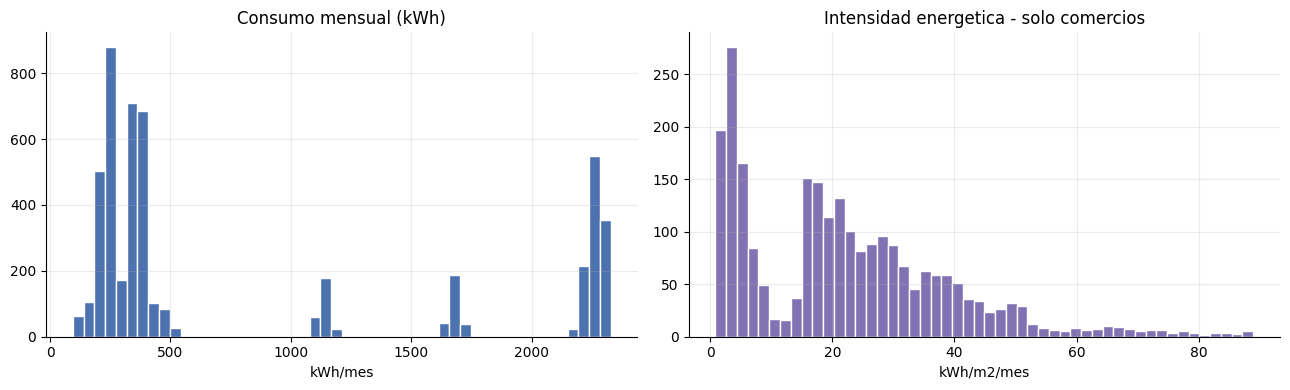

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(ds.consumo_kwh_mes, bins=50, color="#4c72b0", edgecolor="white")
axes[0].set_title("Consumo mensual (kWh)"); axes[0].set_xlabel("kWh/mes")

com = ds[ds.tipo_establecimiento=="Comercio"]
axes[1].hist(com.intensidad_energetica_kwh_m2, bins=50, color="#8172b3", edgecolor="white")
axes[1].set_title("Intensidad energetica - solo comercios"); axes[1].set_xlabel("kWh/m2/mes")
plt.tight_layout(); plt.show()

### 7. Curva de carga horaria

Perfil promedio de consumo por franja y detección de un defecto de datos: porcentajes negativos.

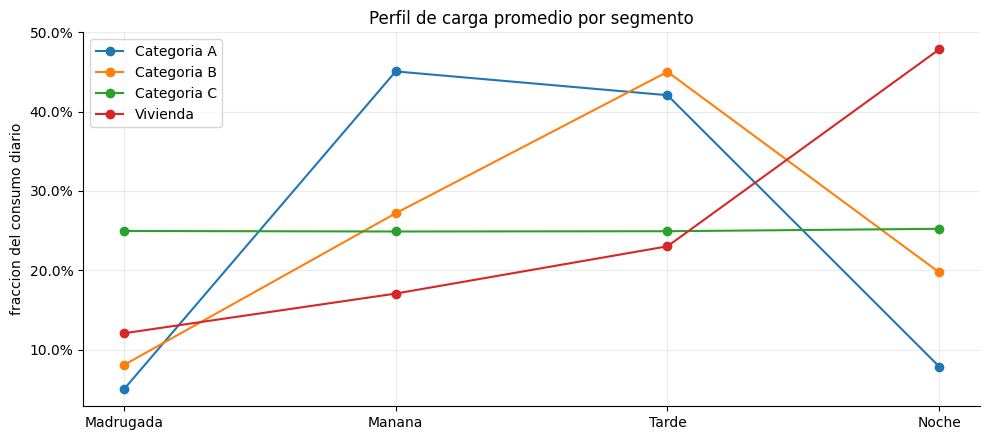

In [ ]:
orden_fr = ["Madrugada","Manana","Tarde","Noche"]
piv = cur.pivot_table(index="id_inmueble", columns="franja_horaria",
                      values="porcentaje_distribucion", aggfunc="first")[orden_fr]
seg = est.set_index("id_inmueble").categoria_comercio
seg = seg.where(est.set_index("id_inmueble").tipo_establecimiento=="Comercio", "Vivienda")
piv2 = piv.join(seg.rename("segmento"))

fig, ax = plt.subplots(figsize=(10,4.5))
for s, g in piv2.groupby("segmento"):
    ax.plot(orden_fr, g[orden_fr].mean().values, marker="o", label=s)
ax.set_title("Perfil de carga promedio por segmento")
ax.set_ylabel("fraccion del consumo diario")
ax.yaxis.set_major_formatter(PercentFormatter(1.0))
ax.legend(); plt.tight_layout(); plt.show()

In [ ]:
# DEFECTO: porcentajes de distribucion negativos (fisicamente imposibles)
neg = cur[cur.porcentaje_distribucion < 0]
neg_join = neg.merge(est[["id_inmueble","tipo_establecimiento","categoria_comercio"]], on="id_inmueble")
print("Registros de curva con porcentaje NEGATIVO:", len(neg))
print("Inmuebles afectados:", neg.id_inmueble.nunique())
print("\nDistribucion por categoria:")
print(neg_join.groupby(["tipo_establecimiento","categoria_comercio"]).size().to_string())
print("\nEjemplo:")
display(neg.head(3))

Registros de curva con porcentaje NEGATIVO: 21
Inmuebles afectados: 21

Distribucion por categoria:
tipo_establecimiento  categoria_comercio
Comercio              Categoria A           21

Ejemplo:


,id_curva,id_inmueble,franja_horaria,porcentaje_distribucion
463,C-00464,COM-00116,Noche,-0.0004
499,C-00500,COM-00125,Noche,-0.0148
1299,C-01300,COM-00325,Noche,-0.0009


**Hallazgo de calidad.** 21 inmuebles (todos Categoría A) tienen una franja con porcentaje de distribución negativo. Es físicamente imposible: una franja no puede representar un porcentaje negativo del consumo diario. Origen: en el generador, para oficinas la suma de mañana + tarde + madrugada puede exceder 1.0 y la franja noche queda negativa. Debe corregirse en la regeneración del dataset (acotar la franja noche a un mínimo positivo y renormalizar las cuatro franjas).

### 8. La variable objetivo y el desbalance por segmento

El `efficiency_label` es el target candidato. A nivel global parece razonablemente balanceado, pero eso es un espejismo: mezcla dos segmentos con sesgos opuestos.

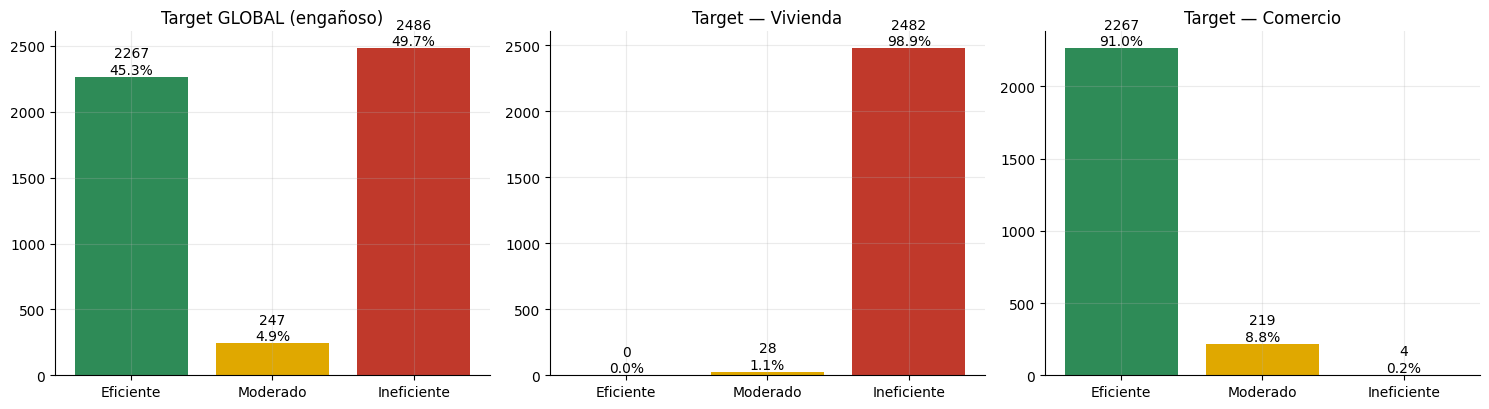

Conteo global del target:
efficiency_label
Ineficiente    2486
Eficiente      2267
Moderado        247


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# Global
g = ds.efficiency_label.value_counts().reindex(PERF_ORDER)
axes[0].bar(PERF_ORDER, g.values, color=[PERF_COLORS[p] for p in PERF_ORDER])
axes[0].set_title("Target GLOBAL (engañoso)")
for i,v in enumerate(g.values): axes[0].text(i, v, f"{v}\n{v/len(ds)*100:.1f}%", ha="center", va="bottom")

# Por segmento
for ax, seg_name in zip(axes[1:], ["Vivienda","Comercio"]):
    sub = ds[ds.tipo_establecimiento==seg_name].efficiency_label.value_counts().reindex(PERF_ORDER).fillna(0)
    ax.bar(PERF_ORDER, sub.values, color=[PERF_COLORS[p] for p in PERF_ORDER])
    ax.set_title(f"Target — {seg_name}")
    tot = sub.sum()
    for i,v in enumerate(sub.values): ax.text(i, v, f"{int(v)}\n{v/tot*100:.1f}%", ha="center", va="bottom")
plt.tight_layout(); plt.show()

print("Conteo global del target:")
print(ds.efficiency_label.value_counts().to_string())

**Hallazgo crítico para modelado.** Por segmento el target es casi de una sola clase:

Viviendas: ~99% Ineficiente, 0% Eficiente (la clase Eficiente es inalcanzable: una casa con nevera operando 24 h no baja del umbral de 3.5 kWh/día).
Comercios: ~91% Eficiente, ~0% Ineficiente.
Moderado casi no existe (247 de 5000 filas).
Un clasificador entrenado sobre el pool aprendería a distinguir vivienda vs comercio, no eficiencia.

### 9. Fuga de etiqueta (data leakage)

El efficiency_label se calcula por umbral duro sobre consumo_kwh_dia (viviendas) e intensidad_energetica_kwh_m2 (comercios). Ambas columnas están en el set de features, por lo que el modelo puede "copiar" la respuesta.

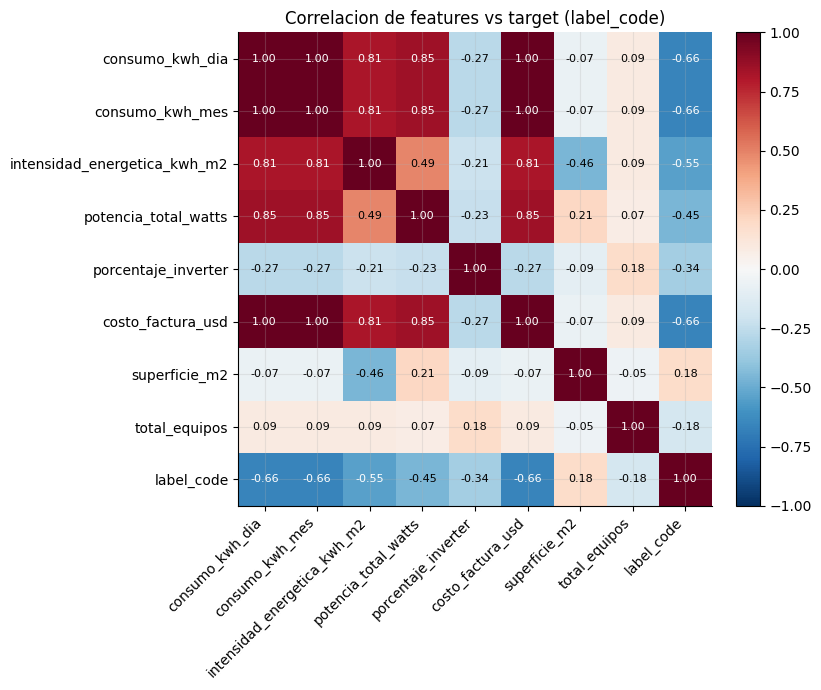

In [ ]:
# Matriz de correlacion entre features numericos y el target codificado
ds2 = ds.copy()
ds2["label_code"] = ds2.efficiency_label.map({"Eficiente":0,"Moderado":1,"Ineficiente":2})
corr_cols = ["consumo_kwh_dia","consumo_kwh_mes","intensidad_energetica_kwh_m2",
             "potencia_total_watts","porcentaje_inverter","costo_factura_usd",
             "superficie_m2","total_equipos","label_code"]
corr = ds2[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8.5,7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols))); ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticks(range(len(corr_cols))); ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center",
                color="white" if abs(corr.iloc[i,j])>0.5 else "black", fontsize=8)
fig.colorbar(im, fraction=0.046, pad=0.04)
ax.set_title("Correlacion de features vs target (label_code)")
plt.tight_layout(); plt.show()

In [ ]:
# Demostracion directa de la fuga: una sola columna reproduce el label
viv = ds[ds.tipo_establecimiento=="Vivienda"]
lab_viv = pd.cut(viv.consumo_kwh_dia, [-np.inf,3.5,7.0,np.inf],
                 labels=["Eficiente","Moderado","Ineficiente"], right=False).astype(str)
acc_viv = (lab_viv.values == viv.efficiency_label.values).mean()

com = ds[ds.tipo_establecimiento=="Comercio"].copy()
def perfil_com(r):
    ie=r.intensidad_energetica_kwh_m2; c=r.categoria_comercio
    lo,hi = (8,15) if c=="Categoria A" else (40,65) if c=="Categoria B" else (70,110)
    return "Eficiente" if ie<lo else ("Moderado" if ie<=hi else "Ineficiente")
acc_com = (com.apply(perfil_com, axis=1).values == com.efficiency_label.values).mean()

print(f"Regla de umbral sobre 1 columna reproduce el label:")
print(f"  Viviendas (consumo_kwh_dia)               -> {acc_viv*100:5.1f}% exacto")
print(f"  Comercios (intensidad_energetica_kwh_m2)  -> {acc_com*100:5.1f}% exacto")
print("\nConclusion: el target es deterministico a partir de features presentes = fuga total.")

Regla de umbral sobre 1 columna reproduce el label:
  Viviendas (consumo_kwh_dia)               -> 100.0% exacto
  Comercios (intensidad_energetica_kwh_m2)  -> 100.0% exacto

Conclusion: el target es deterministico a partir de features presentes = fuga total.


**Implicación.** Con consumo_kwh_dia / intensidad_energetica_kwh_m2 en el set, cualquier árbol trivial alcanza ~100% de accuracy sin aprender nada útil. Para un modelo con valor real hay que eliminar del set las columnas derivadas del propio cálculo (consumo_kwh_*, intensidad_energetica_kwh_m2, costo_*) y predecir a partir de variables independientes.

### 10. Señal en variables independientes (candidatas para el modelo)

Estas sí son features legítimos: no se derivan del cálculo del perfil. Aquí exploramos si tienen relación con la eficiencia.

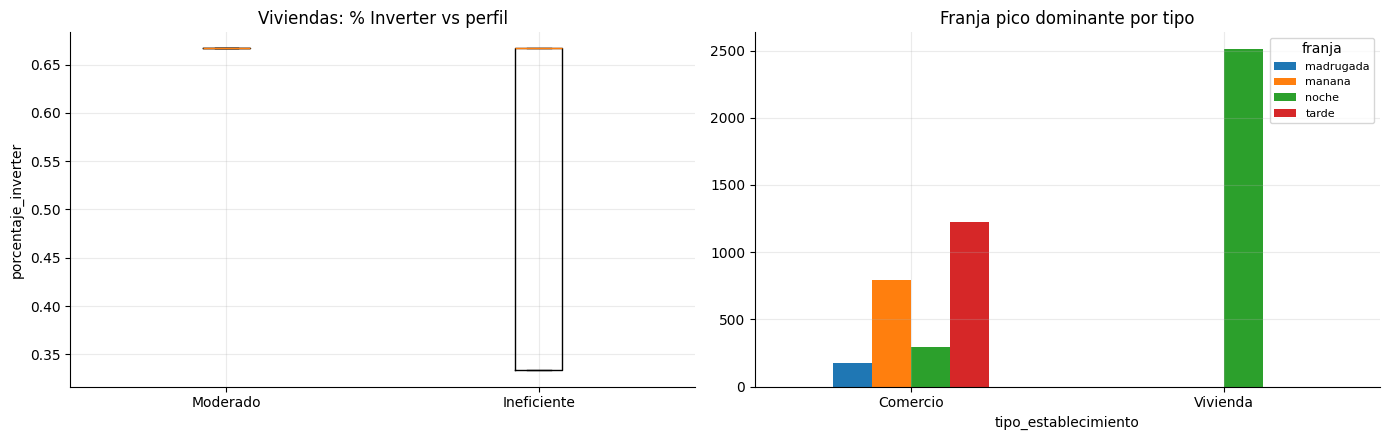

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Inverter % vs perfil (viviendas)
viv = ds[ds.tipo_establecimiento=="Vivienda"]
data_box = [viv[viv.efficiency_label==p].porcentaje_inverter.values for p in PERF_ORDER if (viv.efficiency_label==p).any()]
labels_box = [p for p in PERF_ORDER if (viv.efficiency_label==p).any()]
axes[0].boxplot(data_box)
axes[0].set_xticks(range(1, len(labels_box)+1))
axes[0].set_xticklabels(labels_box)
axes[0].set_title("Viviendas: % Inverter vs perfil")
axes[0].set_ylabel("porcentaje_inverter")

# Franja pico dominante por segmento
pico = ds.groupby(["tipo_establecimiento","franja_pico_dominante"]).size().unstack(fill_value=0)
pico.plot.bar(ax=axes[1])
axes[1].set_title("Franja pico dominante por tipo"); axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title="franja", fontsize=8)
plt.tight_layout(); plt.show()

In [ ]:
# Perfil por pais (para ver si la ubicacion aporta señal)
tab_pais = pd.crosstab(ds.pais_ubicacion, ds.efficiency_label, normalize="index")[PERF_ORDER]*100
tab_pais.round(1)

efficiency_label,Eficiente,Moderado,Ineficiente
pais_ubicacion,,,
Argentina,45.6,4.4,50.1
Brasil,43.0,5.7,51.3
Chile,45.2,5.8,49.0
Colombia,47.4,5.2,47.4
Mexico,44.4,5.4,50.2
Peru,46.3,3.3,50.4


### 11. Limpieza y tratamiento de variables

Con base en el contrato del API (POST /analisis-energetico), conformamos la data al esquema de entrada requerido y corregimos el defecto detectado en la curva de carga. El origen de las variables es el brief del proyecto, no el dataset, son los campos que el backend enviará al modelo.

Esquema requerido: consumo_kwh, uso_horario_pico, cantidad_equipos, tipo_inmueble, horas_alto_consumo -> salida categoria + probabilidad.

#### 11.1 Corrección de las curvas de carga con porcentaje negativo

Se detectaron 21 inmuebles (Categoría A) con una franja negativa. Corregimos acotando cada franja a un piso positivo y renormalizando las cuatro para que sumen 1.0.

In [ ]:
orden_fr = ["Madrugada","Manana","Tarde","Noche"]
piv = cur.pivot_table(index="id_inmueble", columns="franja_horaria",
                      values="porcentaje_distribucion", aggfunc="first")[orden_fr]

mask_neg = (piv < 0).any(axis=1)
print("Inmuebles con franja negativa (ANTES):", int(mask_neg.sum()))

FLOOR = 0.02  # piso positivo por franja
piv_fix = piv.copy()
sub = piv_fix.loc[mask_neg].clip(lower=FLOOR)
sub = sub.div(sub.sum(axis=1), axis=0).round(4)
piv_fix.loc[mask_neg] = sub

print("Inmuebles con franja negativa (DESPUES):", int((piv_fix < 0).any(axis=1).sum()))
print("Sumas fuera de [0.98, 1.02] (DESPUES):",
      int((piv_fix.sum(axis=1).sub(1.0).abs() > 0.02).sum()))

# Tabla larga limpia (por si las derivaciones pendientes la usan)
cur_clean = (piv_fix.reset_index()
             .melt(id_vars="id_inmueble", var_name="franja_horaria",
                   value_name="porcentaje_distribucion"))
cur_clean.to_csv("curva_carga_horaria_LIMPIA.csv", index=False)
print("Guardado: curva_carga_horaria_LIMPIA.csv")

Inmuebles con franja negativa (ANTES): 21
Inmuebles con franja negativa (DESPUES): 0
Sumas fuera de [0.98, 1.02] (DESPUES): 0
Guardado: curva_carga_horaria_LIMPIA.csv


11.2 Conformado al esquema canónico del contrato

Mapeo desde el dataset consolidado hacia los nombres y tipos que espera el API:

| Campo API | Origen | Transformación |
|---|---|---|
| `consumo_kwh` | `consumo_kwh_mes` | directo (mensual) |
| `cantidad_equipos` | `total_equipos` | renombrar |
| `tipo_inmueble` | `tipo_establecimiento` | Vivienda -> "Casa", Comercio -> "Comercio" |
| `categoria` (target) | `efficiency_label` | directo |
| `uso_horario_pico` | — | PENDIENTE (definir con equipo) |
| `horas_alto_consumo` | — | PENDIENTE (definir con equipo) |

In [ ]:
MAP_TIPO = {"Vivienda": "Casa", "Comercio": "Comercio"}

model_df = pd.DataFrame({
    "id_inmueble":        ds.id_inmueble,                        # trazabilidad (no es feature)
    "consumo_kwh":        ds.consumo_kwh_mes.round(2),           # <- consumo_kwh_mes
    "uso_horario_pico":   pd.NA,                                 # PENDIENTE
    "cantidad_equipos":   ds.total_equipos.astype(int),         # <- total_equipos
    "tipo_inmueble":      ds.tipo_establecimiento.map(MAP_TIPO),# Vivienda -> Casa
    "horas_alto_consumo": pd.NA,                                 # PENDIENTE
    "categoria":          ds.efficiency_label,                   # target
})
model_df.head(8)

,id_inmueble,consumo_kwh,uso_horario_pico,cantidad_equipos,tipo_inmueble,horas_alto_consumo,categoria
0,VIV-00001,330.85,<NA>,13,Casa,<NA>,Ineficiente
1,VIV-00002,235.10,<NA>,17,Casa,<NA>,Ineficiente
2,COM-00003,2221.32,<NA>,22,Comercio,<NA>,Eficiente
3,VIV-00004,247.87,<NA>,25,Casa,<NA>,Ineficiente
4,COM-00005,2263.91,<NA>,21,Comercio,<NA>,Eficiente
5,VIV-00006,391.59,<NA>,32,Casa,<NA>,Ineficiente
6,COM-00007,2259.25,<NA>,21,Comercio,<NA>,Eficiente
7,COM-00008,2227.12,<NA>,26,Comercio,<NA>,Eficiente


#### 11.3 Validación y exportación del dataset conformado

In [ ]:
print("Shape:", model_df.shape)
print("\nTipos de dato:"); print(model_df.dtypes.to_string())
print("\nNulos por columna (esperados SOLO en las 2 columnas pendientes):")
print(model_df.isna().sum().to_string())
print("\ntipo_inmueble:", dict(model_df.tipo_inmueble.value_counts()))
print("categoria    :", dict(model_df.categoria.value_counts()))

model_df.to_csv("consumo_energia_sintetico.csv", index=False)
print("\nGuardado: consumo_energia_sintetico.csv  (dataset conformado para modelado)")

Shape: (5000, 7)

Tipos de dato:
id_inmueble            object
consumo_kwh           float64
uso_horario_pico       object
cantidad_equipos        int64
tipo_inmueble          object
horas_alto_consumo     object
categoria              object

Nulos por columna (esperados SOLO en las 2 columnas pendientes):
id_inmueble              0
consumo_kwh              0
uso_horario_pico      5000
cantidad_equipos         0
tipo_inmueble            0
horas_alto_consumo    5000
categoria                0

tipo_inmueble: {'Casa': np.int64(2510), 'Comercio': np.int64(2490)}
categoria    : {'Ineficiente': np.int64(2486), 'Eficiente': np.int64(2267), 'Moderado': np.int64(247)}

Guardado: consumo_energia_sintetico.csv  (dataset conformado para modelado)


**Pendiente de definir con el equipo** (por eso estas dos columnas quedan nulas):

`uso_horario_pico` (bool): propuesta — True si `franja_pico_dominante` está en la ventana pico (Tarde o Noche).

`horas_alto_consumo` (int): propuesta — suma de `horas_uso_estimadas_dia` de los equipos por encima del consumo medio del inmueble.

Ambas deben derivarse de la curva ya corregida (`curva_carga_horaria_LIMPIA.csv`). Una vez acordadas las reglas, se rellenan estas dos columnas y el dataset queda 100% listo para entrenamiento.

### 12. Conclusiones y recomendación para la fase de modelado

**Calidad de la data**: la data corregida es sólida a nivel de integridad y reglas de negocio. Sin nulos, sin llaves duplicadas, sin huérfanos; consumos, costos y perfiles recalculan exactamente contra el diccionario y el benchmark. Es apta para construir el motor de reglas / diagnóstico del backend de inmediato.

**Defecto puntual a corregir**: 21 curvas de carga (Categoría A) con porcentaje de distribución negativo. Corregir el generador y regenerar el dataset.

**No apta tal cual para un clasificador supervisado**, por diseño (no por data sucia):

- Fuga de etiqueta. El `efficiency_label` es una función determinística por umbral de columnas que están en el set de features. Accuracy artificialmente perfecta, cero valor predictivo.

- Clases degeneradas por segmento. Viviendas casi todas Ineficiente (0% Eficiente); comercios casi todos Eficiente; Moderado casi ausente.